# Quiz 4

BEFORE YOU START THIS QUIZ:

1. Click on "Copy to Drive" to make a copy of the quiz,

2. Click on "Share",
    
3. Click on "Change" and select "Anyone with this link can edit"
    
4. Click "Copy link" and

5. Paste the link into [this Canvas assignment](https://canvas.olin.edu/courses/390/assignments/6207).

DO THIS BEFORE YOU START THE QUIZ.

The following cells define functions we have used before.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def decorate(**options):
    """Decorate the current axes.

    Call decorate with keyword arguments like
    decorate(title='Title',
             xlabel='x',
             ylabel='y')

    The keyword arguments can be any of the axis properties
    https://matplotlib.org/api/axes_api.html
    """
    ax = plt.gca()
    ax.set(**options)

    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(handles, labels)

    plt.tight_layout()

The following cell installs `empiricaldist` if needed.

In [3]:
try:
    import empiricaldist
except ImportError:
    !pip install empiricaldist

## Heights and Weights

The following cell downloads data from the Anthropometric Survey of US Army Personnel, abbreviated ANSUR II.

In [4]:
from os.path import basename, exists


def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + local)


download(
    "https://github.com/AllenDowney/DataScience/raw/master/data/ANSURIIFEMALEPublic.csv"
)

The following cell loads the data for the 1,986 female participants in the survey.

In [5]:
ansur_female = pd.read_csv("ANSURIIFEMALEPublic.csv", encoding="ISO-8859-1")
ansur_female.shape

(1986, 108)

The column named `stature` contains height in mm, which I will convert to cm.

In [6]:
# divide by 10 to convert from mm to cm

height = ansur_female["stature"] / 10

**Question 1:** Make a `Pmf` object that contains the PMF of the values in `height` and plot it as a line plot.

Label the axes of the figure (you can use `decorate` or Pyplot functions).

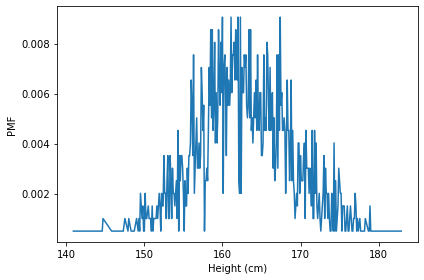

In [7]:
# Solution

from empiricaldist import Pmf

pmf_height = Pmf.from_seq(height)
pmf_height.plot()

decorate(xlabel="Height (cm)", ylabel="PMF")

**NOTE:** In the interest of time, you do not have to label the axes for the other figures on this quiz, but if you have time, it's a good habit to practice.

**Question 2:** Compute the mean and standard deviation of the values in `height`.
Then create a `norm` object (defined in `scipy.stats`) with the same mean and standard deviation.
Use the `norm` object to compute the PDF of the normal distribution for a range of values of `xs` from 140 to 190 cm.
Use `plt.plot` to plot the results; it should look like a bell curve.

In [8]:
# Here's the import statement you'll need
# and a range of values for the xs

from scipy.stats import norm

xs = np.linspace(140, 190)

<AxesSubplot:>

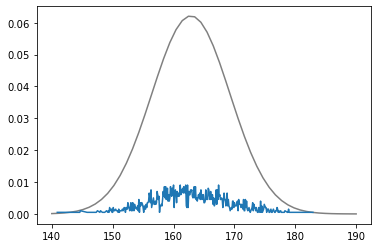

In [9]:
# Solution

mu, sigma = height.mean(), height.std()
ys = norm(mu, sigma).pdf(xs)
plt.plot(xs, ys, color="gray", label="Normal PDF")

pmf_height.plot()

**Question 3:** Use `sns.kdeplot` to make and plot a Kernel Density Estimate (KDE) for the values in `height`. Also plot the PDF of the normal distribution you computed in the previous question.

You should see that the KDE fits the PDF pretty well.

<AxesSubplot:xlabel='stature', ylabel='Density'>

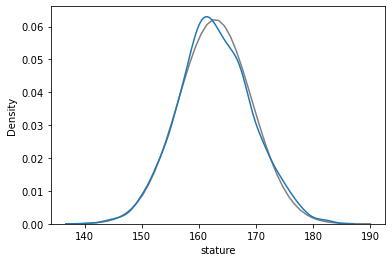

In [10]:
# Solution

plt.plot(xs, ys, color="gray", label="Normal PDF")

sns.kdeplot(height)

**Question 4:** Make a `Cdf` object that represents the CDF of the values in `height` and plot it as a line plot.

<AxesSubplot:>

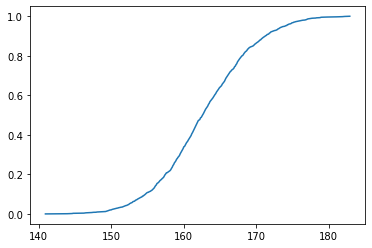

In [11]:
# Solution

from empiricaldist import Cdf

cdf_height = Cdf.from_seq(height)
cdf_height.plot()

**Question 5:** Using a `norm` object again, compute the CDF of a normal distribution with the same mean and standard deviation as `height`, evaluated at a range of values between 140 and 190 cm. Use `plt.plot` to plot the results.

Also plot the CDF of the values in `height`.

You should see that the distribution of heights is well approximated by a normal distribution.

<AxesSubplot:>

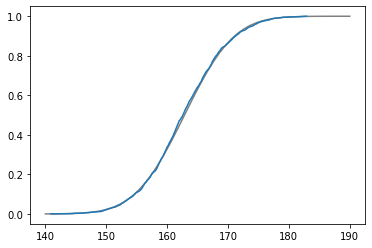

In [12]:
# Solution

ys = norm(mu, sigma).cdf(xs)
plt.plot(xs, ys, color="gray", label="Normal CDF")

cdf_height.plot()

**Question 7:** Using the `Cdf` object, compute the fraction of survey participants who are between 160 and 170 cm (excluding 160 and including 170).

In [13]:
# Solution

cdf_height(170) - cdf_height(160)

0.5246727089627392

**Question 8:** Using the `Cdf` object again, compute the interquartile range (IQR) of this distribution.

In [14]:
# Solution

cdf_height.inverse(0.75) - cdf_height.inverse(0.25)

8.599999999999994

You can ignore the following cells.

<AxesSubplot:>

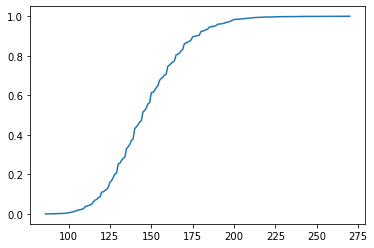

In [15]:
# Solution

weight = ansur_female["Weightlbs"]

cdf_weight = Cdf.from_seq(weight)
cdf_weight.plot()

<AxesSubplot:>

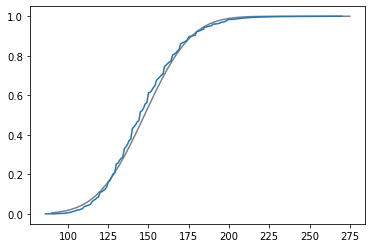

In [16]:
# Solution

mu, sigma = weight.mean(), weight.std()

xs = np.linspace(90, 275)
ys = norm(mu, sigma).cdf(xs)
plt.plot(xs, ys, color="gray", label="Normal CDF")

cdf_weight.plot()

<AxesSubplot:>

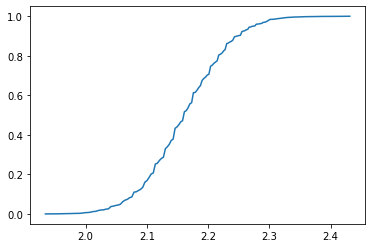

In [17]:
# Solution

log_weight = np.log10(weight)

cdf_log_weight = Cdf.from_seq(log_weight)
cdf_log_weight.plot()

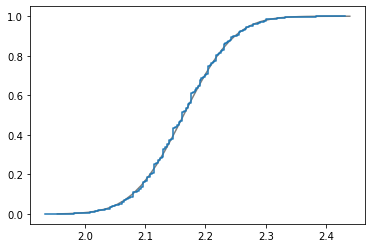

In [18]:
# Solution

mu, sigma = log_weight.mean(), log_weight.std()

xs = np.linspace(90, 275)
xs = np.log10(xs)
ys = norm(mu, sigma).cdf(xs)
plt.plot(xs, ys, color="gray", label="Normal CDF")

cdf_log_weight.step()

## Cities and Populations

The following cell downloads a dataset from the U.S. Census Bureau that contains the populations of cities and towns in the United States.

In [19]:
download(
    "https://www2.census.gov/programs-surveys/popest/datasets/2010-2020/cities/SUB-EST2020_ALL.csv"
)

The following cell reads the data.

In [20]:
pop_frame = pd.read_csv("SUB-EST2020_ALL.csv", encoding="ISO-8859-1")
pop_frame.shape

(81415, 24)

The following cell selects the column containing populations and removes the entries with population 0.

In [21]:
pop_series = pop_frame["POPESTIMATE2020"].replace(0, np.nan).dropna()

This dataset includes population totals for states and counties, in addition to cities and towns, but for the sake of simplicity, we won't bother to separate them.

**Question 9**: Plot the CDF of the populations in this dataset with the x-axis on a log scale.

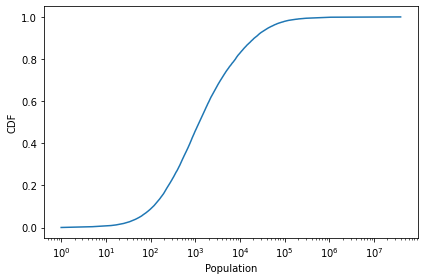

In [22]:
# Solution

cdf_pop = Cdf.from_seq(pop_series)
cdf_pop.plot()

decorate(xlabel="Population", ylabel="CDF", xscale="log")

**Question 10:** People who study [human geography](https://www.youtube.com/watch?v=ON4oIKza7bw) often describe the distribution of population sizes using a [rank-size plot](https://en.wikipedia.org/wiki/Rank%E2%80%93size_distribution), which shows populations on the y-axis and "ranks" on the x-axis.

The rank of the biggest city is 1, the rank of the second-biggest city is 2, and so on.

Use `sort_values` to sort the values in `pop_series`; then use `np.arange` to make an array of ranks starting from 1.

Plot the sorted populations on the y-axis and the ranks on the x-axis, and put the y-axis on a log scale.

If you compare the result to the previous figure, you might note a relationship between the rank-size plot and the CDF.

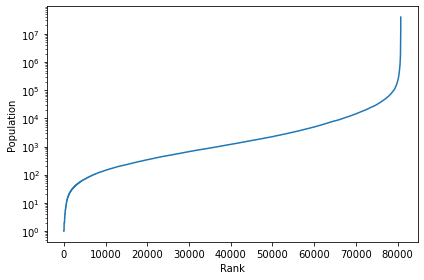

In [25]:
# Solution

ranks = np.arange(1, len(pop_series) + 1)
pops = pop_series.sort_values()

plt.plot(ranks, pops)

decorate(xlabel="Rank", ylabel="Population", yscale="log")

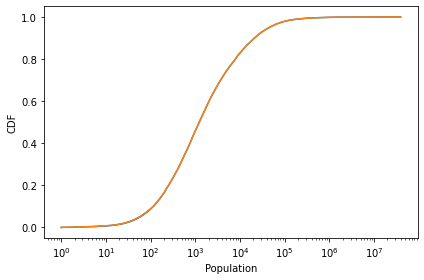

In [26]:
# Solution

ps = (ranks - 1) / len(pop_series)
plt.plot(pops, ps)
cdf_pop.plot()

decorate(xlabel="Population", ylabel="CDF", xscale="log")

*Elements of Data Science*

Copyright 2022 Allen Downey

License: [Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International](https://creativecommons.org/licenses/by-nc-sa/4.0/)